In [1]:
import h5py
import os
import sys
#import tensorflow as tf
import numpy as np



In [2]:
import math
import torch
import torch.nn as nn
import numpy as np
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

/global/homes/k/kberard/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
def D_JS(p1,p2,tol=1e-16):
    p1 = p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [4]:
# minorized reference
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]
#print(ref_d)
ref_d = np.sum(ref_d,axis=2)
print(ref_d.shape)


data = np.load("/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Minorized_2d/DFT_dat_lev2427000_sample_training_data.npz")
x_train = data['x_train']
x_val   = data['x_val']
y_train = data['y_train']
y_val   = data['y_val']
n_samples = data["total_samples"]


data = 0
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]
test_d = np.sum(test_d,axis=2)

(64, 64)


In [5]:
import numpy as np
import os

def encode_voxel_to_rgb(x_train_3d, x_val_3d, x_test_3d,
                        y_train_3d, y_val_3d, y_test_3d,
                        ref_d=None, save_dir='scalers'):
    """
    Encode a batch of 3D volumes by normalizing each depth slice independently and replicating to RGB.
    Each input of shape (N, 64, 64, 64) is transformed into (N*64, 64, 64, 3).

    Args:
        *_3d: ndarray of shape (N, 64, 64, 64)
        ref_d: optional ndarray of shape (64, 64, 64)
        save_dir: directory to save the (min, max) scalers for each batch

    Returns:
        Tuple of:
            x_train_rgb, x_val_rgb, x_test_rgb,
            y_train_rgb, y_val_rgb, y_test_rgb,
            ref_d_rgb (or None if not provided)
    """
    os.makedirs(save_dir, exist_ok=True)

    def process_batch(batch, tag):
        N, D, H, W = batch.shape  # (N, 64, 64, 64)
        rgb_batch = np.zeros((N * D, H, W, 3), dtype=np.float32)
        all_mins = []
        all_maxs = []

        for i in range(N):
            mins = []
            maxs = []
            for d in range(D):
                slice_2d = batch[i, d, :, :]
                s_min = float(slice_2d.min())
                s_max = float(slice_2d.max())

                if s_max == s_min:
                    s_max = s_min + 1e-6  # prevent divide-by-zero

                normed = (slice_2d - s_min) / (s_max - s_min)
                rgb = np.stack([normed] * 3, axis=-1)  # shape: (64, 64, 3)

                rgb_batch[i * D + d] = rgb
                mins.append(s_min)
                maxs.append(s_max)

            all_mins.append(mins)
            all_maxs.append(maxs)

        np.savez(os.path.join(save_dir, f'{tag}_scalers.npz'),
                 mins=np.array(all_mins), maxs=np.array(all_maxs))

        return rgb_batch

    x_train_rgb = process_batch(x_train_3d, 'x_train')
    x_val_rgb   = process_batch(x_val_3d, 'x_val')

    y_train_rgb = process_batch(y_train_3d, 'y_train')
    y_val_rgb   = process_batch(y_val_3d, 'y_val')


    # Optional: single ref volume
    ref_d_rgb = None
    if ref_d is not None:
        ref_rgb = np.zeros((64, 64, 64, 3), dtype=np.float32)
        ref_mins = []
        ref_maxs = []
        for d in range(64):
            slice_2d = ref_d[d, :, :]
            s_min = float(slice_2d.min())
            s_max = float(slice_2d.max())

            if s_max == s_min:
                s_max = s_min + 1e-6

            normed = (slice_2d - s_min) / (s_max - s_min)
            ref_rgb[d] = np.stack([normed] * 3, axis=-1)
            ref_mins.append(s_min)
            ref_maxs.append(s_max)

        np.savez(os.path.join(save_dir, 'ref_d_scalers.npz'),
                 mins=np.array(ref_mins), maxs=np.array(ref_maxs))
        ref_d_rgb = ref_rgb

    return (
        x_train_rgb, x_val_rgb, None,
        y_train_rgb, y_val_rgb, None,
        ref_d_rgb
    )


In [6]:
import numpy as np

def decode_rgb_to_voxel_batch(rgb_data, scaler_path):
    """
    Decode RGB-encoded batch (N*64, 64, 64, 3) back to original (N, 64, 64, 64) data
    using per-slice min/max scalers.

    Args:
        rgb_data: ndarray of shape (N*64, 64, 64, 3)
        scaler_path: path to `.npz` file containing 'mins' and 'maxs' arrays
                     of shape (N, 64)

    Returns:
        reconstructed: ndarray of shape (N, 64, 64, 64)
    """
    num_slices = 64
    assert rgb_data.ndim == 4 and rgb_data.shape[1:4] == (64, 64, 3), \
        f"Expected shape (N*64, 64, 64, 3), got {rgb_data.shape}"

    N = rgb_data.shape[0] // num_slices
    assert rgb_data.shape[0] == N * num_slices, "RGB data is not a multiple of 64 slices"

    scalers = np.load(scaler_path)
    mins = scalers['mins']  # shape (N, 64)
    maxs = scalers['maxs']  # shape (N, 64)

    reconstructed = np.zeros((N, 64, 64, 64), dtype=np.float32)

    for i in range(N):
        for d in range(num_slices):
            idx = i * num_slices + d
            normed = rgb_data[idx, :, :, 0]  # Use first channel (R), they are all the same
            s_min = mins[i, d]
            s_max = maxs[i, d]
            reconstructed[i, d, :, :] = normed * (s_max - s_min) + s_min

    return reconstructed


In [7]:
def encode_density2d_to_rgb(
    x_train_2d, x_val_2d, x_test_2d,
    y_train_2d, y_val_2d, y_test_2d,
    ref_d=None, save_dir='scalers_2d'
):
    import numpy as np
    import os

    os.makedirs(save_dir, exist_ok=True)

    def process_batch(batch, tag):
        if batch is None:
            return None

        N, H, W = batch.shape
        rgb_batch = np.zeros((N, H, W, 3), dtype=np.float32)
        mins = np.zeros(N)
        maxs = np.zeros(N)

        for i in range(N):
            s_min = float(batch[i].min())
            s_max = float(batch[i].max())
            if s_max == s_min:
                s_max = s_min + 1e-6

            normed = (batch[i] - s_min) / (s_max - s_min)
            rgb_batch[i] = np.stack([normed] * 3, axis=-1)

            mins[i] = s_min
            maxs[i] = s_max

        np.savez(os.path.join(save_dir, f'{tag}_scalers.npz'),
                 mins=mins, maxs=maxs)

        return rgb_batch

    x_train_rgb = process_batch(x_train_2d, 'x_train')
    x_val_rgb   = process_batch(x_val_2d,   'x_val')
    x_test_rgb  = process_batch(x_test_2d,  'x_test')

    y_train_rgb = process_batch(y_train_2d, 'y_train')
    y_val_rgb   = process_batch(y_val_2d,   'y_val')
    y_test_rgb  = process_batch(y_test_2d,  'y_test')

    ref_d_rgb = None
    if ref_d is not None:
        s_min = float(ref_d.min())
        s_max = float(ref_d.max())
        if s_max == s_min:
            s_max = s_min + 1e-6
        normed = (ref_d - s_min) / (s_max - s_min)
        ref_d_rgb = np.stack([normed] * 3, axis=-1)

        np.savez(os.path.join(save_dir, 'ref_d_scalers.npz'),
                 mins=np.array([s_min]),
                 maxs=np.array([s_max]))

    return (
        x_train_rgb, x_val_rgb, x_test_rgb,
        y_train_rgb, y_val_rgb, y_test_rgb,
        ref_d_rgb
    )


import numpy as np

def decode_rgb_to_density2d_batch(rgb_data, scaler_path):
    """
    Decode RGB-encoded 2D densities back to original values.

    Args:
        rgb_data: ndarray of shape (N, 64, 64, 3) or None
        scaler_path: path to `.npz` file containing:
                     mins: shape (N,)
                     maxs: shape (N,)

    Returns:
        reconstructed: ndarray of shape (N, 64, 64) or None
    """

    if rgb_data is None:
        return None

    assert rgb_data.ndim == 4 and rgb_data.shape[-1] == 3, \
        f"Expected (N, 64, 64, 3), got {rgb_data.shape}"

    scalers = np.load(scaler_path)
    mins = scalers['mins']
    maxs = scalers['maxs']

    N, H, W, _ = rgb_data.shape
    assert mins.shape[0] == N, "Scaler size mismatch"

    reconstructed = np.zeros((N, H, W), dtype=np.float32)

    for i in range(N):
        normed = rgb_data[i, :, :, 0]  # all channels identical
        reconstructed[i] = normed * (maxs[i] - mins[i]) + mins[i]

    return reconstructed



In [8]:
x_train_rgb, x_val_rgb, x_test_rgb, \
y_train_rgb, y_val_rgb, y_test_rgb, \
ref_d_rgb = encode_density2d_to_rgb(
    x_train, x_val, None,
    y_train, y_val, None,
    ref_d=ref_d
)
print("done generating")

done generating


In [9]:
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir)
from models.network_scunet import SCUNet as SCUNet
import numpy as np

from torch.utils.data import Dataset
import torch
import numpy as np

class RGBDenoiseDataset(Dataset):
    def __init__(self, x, y):
        # Normalize to [0, 1] and permute axes to (N, C, H, W)
        self.x = torch.tensor(np.transpose(x, (0, 3, 1, 2)), dtype=torch.float32) 
        self.y = torch.tensor(np.transpose(y, (0, 3, 1, 2)), dtype=torch.float32) 

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]




In [10]:
print("here")

here


In [11]:
from torch.utils.data import DataLoader

# Datasets
train_dataset = RGBDenoiseDataset(x_train_rgb, y_train_rgb)
val_dataset   = RGBDenoiseDataset(x_val_rgb, y_val_rgb)
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)


In [12]:
from tqdm import tqdm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SCUNet(in_nc=3, input_resolution=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for step, (noisy, clean) in enumerate(progress_bar):
        noisy, clean = noisy.to(device), clean.to(device)
        
        optimizer.zero_grad()
        output = model(noisy)
        loss = loss_fn(output, clean)
        loss.backward()
        optimizer.step()
        
        # Track running loss
        running_loss += loss.item()
        avg_loss = running_loss / (step + 1)

        # Show live loss in progress bar
        progress_bar.set_postfix({"Loss": f"{avg_loss:.6f}"})

    print(f"Epoch {epoch+1} finished. Average Loss: {avg_loss:.6f}")

model.eval()


Using device: cuda
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000


Epoch 1/50: 100%|██████████| 32/32 [00:03<00:00, 10.09batch/s, Loss=0.034619]


Epoch 1 finished. Average Loss: 0.034619


Epoch 2/50: 100%|██████████| 32/32 [00:02<00:00, 11.95batch/s, Loss=0.004451]


Epoch 2 finished. Average Loss: 0.004451


...

Epoch 49/50: 100%|██████████| 32/32 [00:02<00:00, 12.09batch/s, Loss=0.000506]


Epoch 49 finished. Average Loss: 0.000506


Epoch 50/50: 100%|██████████| 32/32 [00:02<00:00, 12.06batch/s, Loss=0.000498]

Epoch 50 finished. Average Loss: 0.000498


SCUNet(
  (m_head): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (m_down1): Sequential(
    (0): ConvTransBlock(
      (trans_block): Block(
        (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (msa): WMSA(
          (embedding_layer): Linear(in_features=32, out_features=96, bias=True)
          (linear): Linear(in_features=32, out_features=32, bias=True)
        )
        (drop_path): Identity()
        (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=32, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=128, out_features=32, bias=True)
        )
      )
      (conv1_1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv1_2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv_block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), pa

In [13]:
torch.save(model, str(n_samples)+('minor_2d_scunet_trained'))
"""import torch
from models.network_scunet import SCUNet  # wherever your SCUNet is defined
torch.serialization.add_safe_globals([SCUNet])

model = torch.load('scunet_trained', weights_only=False)
model.eval()"""


"import torch\nfrom models.network_scunet import SCUNet  # wherever your SCUNet is defined\ntorch.serialization.add_safe_globals([SCUNet])\n\nmodel = torch.load('scunet_trained', weights_only=False)\nmodel.eval()"

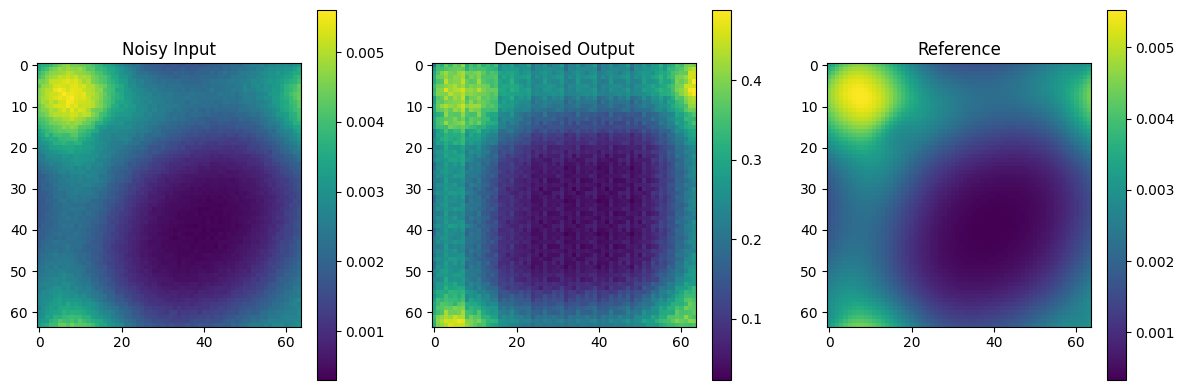

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare input (3-channel!)
# ------------------------------------------------------------
# test_d shape: (64, 64), noisy density
test_input = np.stack([test_d]*3, axis=-1)  # -> (64, 64, 3)
test_input = torch.from_numpy(test_input).float().unsqueeze(0)  # -> (1, 64, 64, 3)

# PyTorch expects channel-first format: (B, C, H, W)
test_input = test_input.permute(0, 3, 1, 2).to(device)  # -> (1, 3, 64, 64)

# ------------------------------------------------------------
# Model prediction
# ------------------------------------------------------------
model.eval()
with torch.no_grad():
    denoised = model(test_input)  # -> (1, 3, 64, 64)
    
# Move to CPU and convert to NumPy
denoised_np = denoised.squeeze(0).permute(1, 2, 0).cpu().numpy()  # -> (64, 64, 3)
denoised_2d = denoised_np[..., 0]  # Take first channel for visualization

# ------------------------------------------------------------
# Ground truth
# ------------------------------------------------------------
noisy_input = test_d
true_clean = ref_d

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy_input, cmap='viridis')
plt.title("Noisy Input")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(denoised_2d, cmap='viridis')
plt.title("Denoised Output")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(true_clean, cmap='viridis')
plt.title("Reference")
plt.colorbar()

plt.tight_layout()
plt.show()
